# So sánh mô hình 3D (MMDetection3D, trọng số có sẵn, không train)

Số liệu do `tools3d/run3d.py all` sinh trên máy có GPU: mỗi mô hình chạy trên **các scene thuộc tập val của nuScenes
có đủ dữ liệu trên máy** (mọi trọng số học trên tập train, chấm trên train sẽ bị ảo), chấm bằng bộ chấm chính thức
`nuscenes.eval.detection` giới hạn đúng các sample đã chạy. Phần cuối lấy kết quả của QA Agent 3D (kiểm chứng box bằng
6 camera + LiDAR) trên 3 scene demo từ `python -m src.cli evaluate3d`.

Chạy lại: `.venv-mm3d\Scripts\python tools3d\run3d.py all --dataroot ..\v1.0-trainval`, rồi
`python -m src.cli label3d --model <m>` và `python -m src.cli evaluate3d` cho từng mô hình, rồi *Run All*.

In [ ]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path.cwd().parent if Path.cwd().name == "eval" else Path.cwd()
DET3D = ROOT / "eval" / "results" / "det3d"
if not (DET3D / "summary.json").exists():
    raise FileNotFoundError("Chưa có eval/results/det3d/summary.json: chạy tools3d/run3d.py all trên máy GPU trước")
S = json.loads((DET3D / "summary.json").read_text(encoding="utf-8"))

# thứ tự + màu cố định theo mô hình (không đổi khi thiếu mô hình nào đó)
ORDER = ["pointpillars", "ssn", "ssn_regnet", "centerpoint_pillar", "centerpoint_voxel", "fcos3d", "pgd", "bevfusion"]
COLOR = dict(zip(ORDER, ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7", "#e34948"]))
SENSOR = dict(pointpillars="LiDAR", ssn="LiDAR", ssn_regnet="LiDAR", centerpoint_pillar="LiDAR",
              centerpoint_voxel="LiDAR", fcos3d="Camera", pgd="Camera", bevfusion="LiDAR+Camera")
PUBLISHED = dict(pointpillars=(0.397, 0.532), ssn=(0.409, 0.544), ssn_regnet=(0.467, 0.582),
                 centerpoint_pillar=(0.487, 0.596), centerpoint_voxel=(0.565, 0.652), fcos3d=(0.321, 0.393),
                 pgd=(0.358, 0.425), bevfusion=(0.686, 0.714))  # mAP, NDS công bố trên val đầy đủ (6019 sample)
INK, MUTED, GRID, SURF = "#1f1e1d", "#52514e", "#e7e6e2", "#fcfcfb"
plt.rcParams.update({
    "axes.spines.top": False, "axes.spines.right": False, "axes.edgecolor": "#9a9994", "axes.labelcolor": MUTED,
    "xtick.color": MUTED, "ytick.color": MUTED, "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8,
    "axes.axisbelow": True, "legend.frameon": False, "figure.facecolor": SURF, "axes.facecolor": SURF,
    "font.size": 10, "axes.titlesize": 11, "axes.titleweight": "bold", "axes.titlecolor": INK,
})

models = {m: S["models"][m] for m in ORDER if m in S["models"]}
ok = [m for m in models if "error" not in models[m]]
failed = {m: models[m]["error"] for m in models if "error" in models[m]}
print(f"{len(S['scenes'])} scene val, {S['n_samples']} sample: {', '.join(S['scenes'])}")
print("Chạy được:", ", ".join(ok))
for m, e in failed.items():
    print(f"LỖI {m}: {str(e)[:200]}")

27 scene val, 1076 sample: scene-0003, scene-0012, scene-0013, scene-0014, scene-0015, scene-0016, scene-0017, scene-0018, scene-0035, scene-0036, scene-0038, scene-0039, scene-0092, scene-0093, scene-0094, scene-0095, scene-0096, scene-0097, scene-0098, scene-0099, scene-0100, scene-0101, scene-0102, scene-0103, scene-0553, scene-0796, scene-0916
Chạy được: pointpillars, ssn, centerpoint_pillar, centerpoint_voxel, fcos3d, pgd


## Bảng tổng hợp

In [ ]:
rows = []
for m in ok:
    r = models[m]
    te = r["tp_errors"]
    rows.append({
        "mô hình": m, "cảm biến": SENSOR[m], "mAP": r["mAP"], "NDS": r["NDS"],
        "NDS công bố": PUBLISHED[m][1], "s / sample": r.get("s_per_sample"), "VRAM (GB)": r.get("peak_gpu_gb"),
        "ATE (m)": te["trans_err"], "ASE": te["scale_err"], "AOE (rad)": te["orient_err"],
        "AVE (m/s)": te["vel_err"], "AAE": te["attr_err"],
    })
table = pd.DataFrame(rows).set_index("mô hình")
table.style.format(precision=3).background_gradient(subset=["mAP", "NDS"], cmap="Blues")

,cảm biến,mAP,NDS,NDS công bố,s / sample,VRAM (GB),ATE (m),ASE,AOE (rad),AVE (m/s),AAE
mô hình,,,,,,,,,,,
pointpillars,LiDAR,0.470,0.562,0.532,0.849,1.740,0.394,0.268,0.520,0.300,0.246
ssn,LiDAR,0.451,0.569,0.544,0.586,0.570,0.328,0.262,0.407,0.335,0.233
centerpoint_pillar,LiDAR,0.521,0.605,0.596,0.411,0.480,0.298,0.258,0.394,0.364,0.245
centerpoint_voxel,LiDAR,0.573,0.647,0.652,0.624,0.500,0.268,0.242,0.352,0.371,0.166
fcos3d,Camera,0.329,0.411,0.393,2.722,0.550,0.689,0.237,0.510,1.728,0.101
pgd,Camera,0.394,0.446,0.425,2.713,0.560,0.618,0.257,0.445,1.300,0.191


## Độ chính xác: NDS và mAP đo được so với số công bố

Thanh = đo trên các scene val có trên máy; vạch xám = số công bố trên toàn bộ val. Tập nhỏ nên chênh vài điểm là
bình thường, thứ hạng giữa các mô hình mới là điều cần xem.

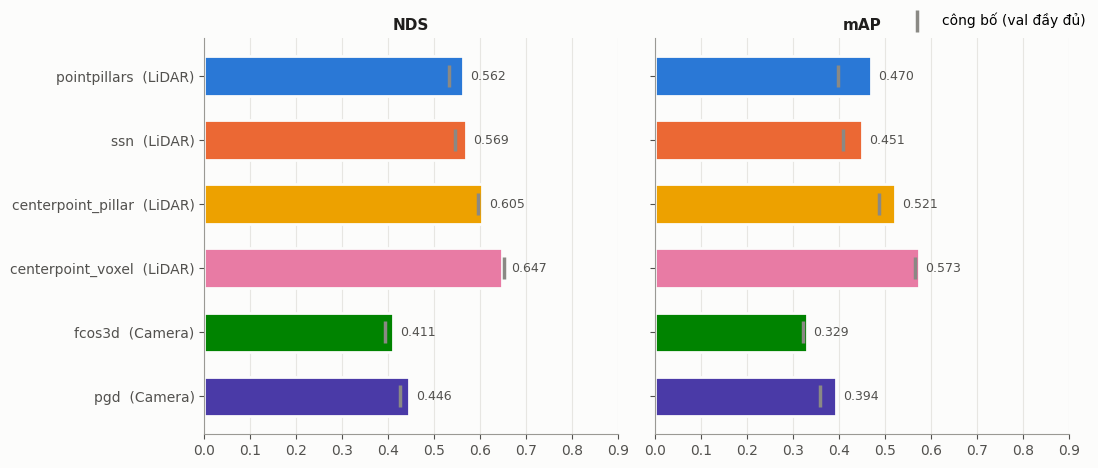

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 0.55 * len(ok) + 1.4), sharey=True)
y = np.arange(len(ok))[::-1]
for ax, key, k in ((axes[0], "NDS", 1), (axes[1], "mAP", 0)):
    vals = [models[m][key] for m in ok]
    ax.barh(y, vals, height=0.62, color=[COLOR[m] for m in ok], edgecolor=SURF, linewidth=2)
    ax.scatter([PUBLISHED[m][k] for m in ok], y, marker="|", s=260, color="#8a8984", linewidths=2.5,
               label="công bố (val đầy đủ)", zorder=3)
    for yi, v, m in zip(y, vals, ok):
        ax.text(max(v, PUBLISHED[m][k]) + 0.015, yi, f"{v:.3f}", va="center", fontsize=9, color=MUTED)
    ax.set_xlim(0, 0.9)
    ax.set_title(key)
    ax.grid(axis="y", visible=False)
axes[0].set_yticks(y, [f"{m}  ({SENSOR[m]})" for m in ok])
fig.legend(*axes[0].get_legend_handles_labels(), loc="upper right", ncol=1)
fig.tight_layout()

## Tốc độ và chất lượng

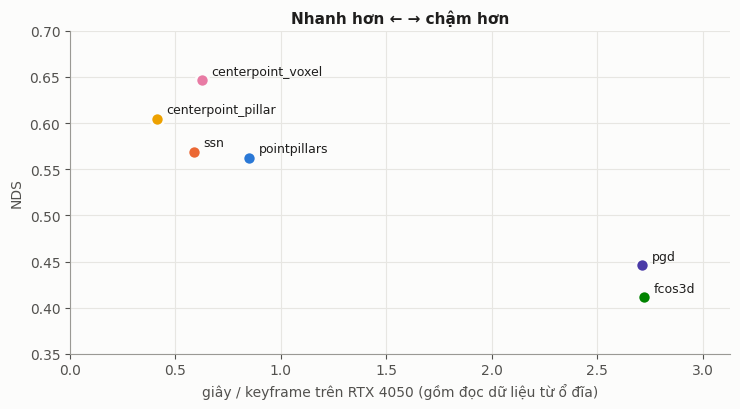

In [ ]:
fig, ax = plt.subplots(figsize=(7.5, 4.2))
for m in ok:
    r = models[m]
    ax.scatter(r["s_per_sample"], r["NDS"], s=90, color=COLOR[m], edgecolor=SURF, linewidth=2, zorder=3)
    ax.annotate(m, (r["s_per_sample"], r["NDS"]), xytext=(7, 4), textcoords="offset points", fontsize=9, color=INK)
ax.set_xlim(0, max(models[m]["s_per_sample"] for m in ok) * 1.15)
ax.set_ylim(0.35, 0.7)
ax.set_xlabel("giây / keyframe trên RTX 4050 (gồm đọc dữ liệu từ ổ đĩa)")
ax.set_ylabel("NDS")
ax.set_title("Nhanh hơn ← → chậm hơn")
fig.tight_layout()

## AP từng lớp (khớp theo khoảng cách tâm, trung bình 0.5 / 1 / 2 / 4 m)

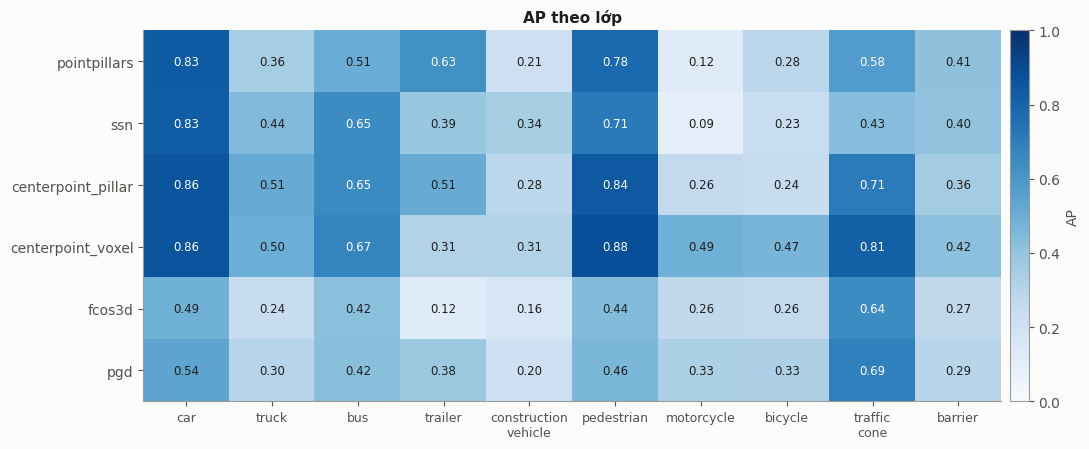

In [ ]:
ap = pd.DataFrame({m: models[m]["ap"] for m in ok}).T.loc[ok]
ap = ap[[c for c in ["car", "truck", "bus", "trailer", "construction_vehicle", "pedestrian", "motorcycle", "bicycle",
                     "traffic_cone", "barrier"] if c in ap.columns]]
fig, ax = plt.subplots(figsize=(11, 0.5 * len(ok) + 1.6))
im = ax.imshow(ap.values, cmap="Blues", vmin=0, vmax=1, aspect="auto")
ax.set_xticks(range(ap.shape[1]), [c.replace("_", "\n") for c in ap.columns], fontsize=9)
ax.set_yticks(range(len(ok)), ok)
ax.grid(False)
for i in range(ap.shape[0]):
    for j in range(ap.shape[1]):
        v = ap.values[i, j]
        ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=8.5, color="white" if v > 0.55 else INK)
fig.colorbar(im, ax=ax, fraction=0.025, pad=0.01, label="AP")
ax.set_title("AP theo lớp")
fig.tight_layout()

## Precision / recall theo ngưỡng điểm

Cùng lớp, tâm cách < 2 m. Mỗi điểm trên đường là một ngưỡng (0.05 → 0.6, từ phải sang trái); dùng để chọn ngưỡng
giữ box khi đưa pre-label cho người duyệt. Thang điểm của mỗi mô hình khác nhau (PGD gần như không có box ≥ 0.4,
CenterPoint thì nhiều), nên `label3d` dùng **ngưỡng riêng cho từng mô hình**: ngưỡng có F1 cao nhất (vòng tròn).

,≥0.05,≥0.1,≥0.2,≥0.3,≥0.4,≥0.5,≥0.6
pointpillars,0.12 / 0.94,0.30 / 0.90,0.60 / 0.77,0.77 / 0.63,0.88 / 0.50,0.93 / 0.37,0.97 / 0.27
ssn,0.14 / 0.93,0.32 / 0.85,0.63 / 0.68,0.82 / 0.52,0.90 / 0.37,0.94 / 0.26,0.97 / 0.18
centerpoint_pillar,0.19 / 0.94,0.19 / 0.94,0.40 / 0.90,0.58 / 0.85,0.71 / 0.79,0.80 / 0.71,0.86 / 0.59
centerpoint_voxel,0.26 / 0.95,0.26 / 0.95,0.48 / 0.91,0.64 / 0.87,0.74 / 0.82,0.81 / 0.75,0.86 / 0.63
fcos3d,0.23 / 0.83,0.41 / 0.78,0.66 / 0.66,0.82 / 0.45,0.92 / 0.19,0.97 / 0.05,0.99 / 0.01
pgd,0.56 / 0.76,0.76 / 0.60,0.91 / 0.18,1.00 / 0.01,0.00 / 0.00,0.00 / 0.00,0.00 / 0.00


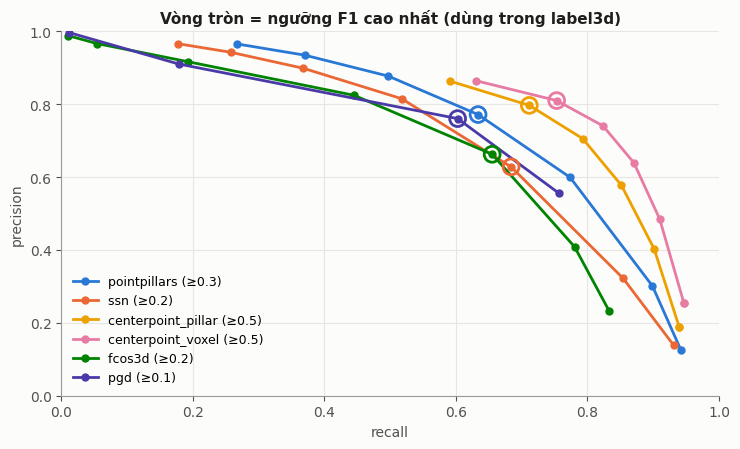

In [ ]:
fig, ax = plt.subplots(figsize=(7.5, 4.6))
for m in ok:
    pr = models[m]["pr"]
    f1 = [2 * p * r / (p + r) if p + r else 0 for p, r in zip(pr["precision"], pr["recall"])]
    i = int(np.argmax(f1))
    keep = [k for k, r in enumerate(pr["recall"]) if r > 0]  # ngưỡng không còn box nào: bỏ
    ax.plot([pr["recall"][k] for k in keep], [pr["precision"][k] for k in keep], "-o", color=COLOR[m], lw=2, ms=5,
            label=f"{m} (≥{pr['thresholds'][i]})")
    ax.scatter(pr["recall"][i], pr["precision"][i], s=130, facecolor="none", edgecolor=COLOR[m], lw=2, zorder=4)
ax.set_xlabel("recall")
ax.set_ylabel("precision")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_title("Vòng tròn = ngưỡng F1 cao nhất (dùng trong label3d)")
ax.legend(loc="lower left", fontsize=9)
fig.tight_layout()

thr = pd.DataFrame({m: dict(zip(models[m]["pr"]["thresholds"],
                                 [f"{p:.2f} / {r:.2f}" for p, r in zip(models[m]["pr"]["precision"],
                                                                      models[m]["pr"]["recall"])])) for m in ok}).T
thr.columns = [f"≥{t}" for t in thr.columns]
thr  # precision / recall

## QA Agent 3D: kiểm chứng bằng camera trên 3 scene demo

Với mỗi box của mô hình, agent (không nhìn nhãn gốc) kết luận DUNG → tự duyệt (low), các kết luận khác → người xem.
So với nhãn gốc (khớp tâm < 2 m):

- **tự duyệt**: tỉ lệ box được kết luận DUNG; **đúng trong nhóm tự duyệt**: bao nhiêu trong đó thật sự đúng
- **bắt được box sai**: trong các box sai lớp / báo nhầm, bao nhiêu bị agent gắn cờ

,box,GT,tự duyệt,đúng (tự duyệt),bắt box sai,flag precision,GT bị sót
pointpillars,2668.000,3559.000,0.536,0.948,0.881,0.443,1514.000
ssn,3468.000,3559.000,0.432,0.920,0.909,0.607,1405.000
centerpoint_pillar,3640.000,3559.000,0.481,0.920,0.866,0.478,962.000
centerpoint_voxel,3697.000,3559.000,0.512,0.931,0.863,0.457,818.000
fcos3d,4111.000,3559.000,0.529,0.798,0.722,0.590,1029.000
pgd,3304.000,3559.000,0.587,0.872,0.744,0.526,1222.000


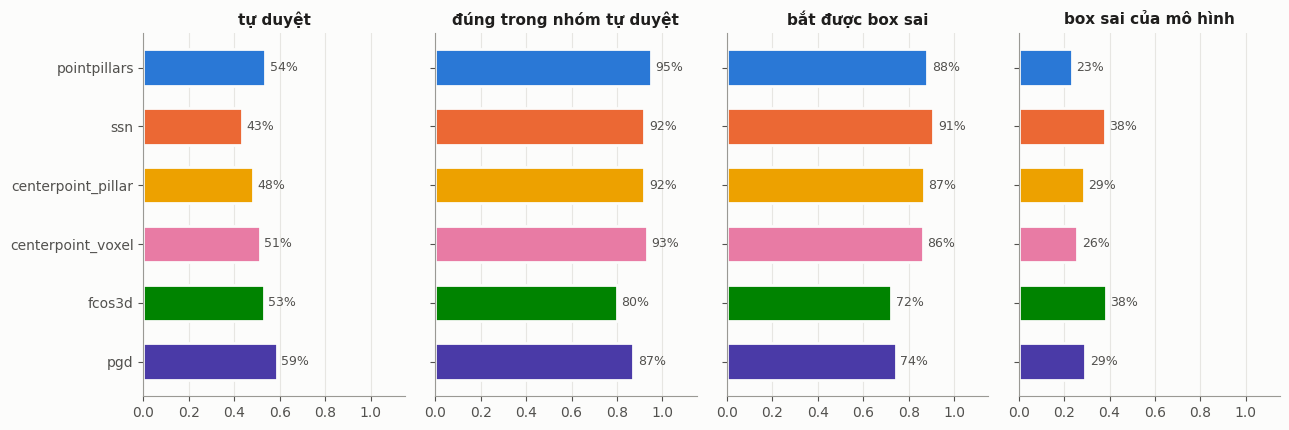

In [ ]:
ver = {m: json.loads((DET3D / m / "verify_eval.json").read_text(encoding="utf-8"))
       for m in ok if (DET3D / m / "verify_eval.json").exists()}
if not ver:
    print("Chưa có verify_eval.json: chạy python -m src.cli label3d --model <m> và python -m src.cli evaluate3d")
else:
    vm = list(ver)
    keys = [("auto_share", "tự duyệt"), ("auto_precision", "đúng trong nhóm tự duyệt"),
            ("error_recall", "bắt được box sai"), ("error_rate_all", "box sai của mô hình")]
    fig, axes = plt.subplots(1, 4, figsize=(13, 0.5 * len(vm) + 1.4), sharey=True)
    y = np.arange(len(vm))[::-1]
    for ax, (k, title) in zip(axes, keys):
        vals = [ver[m][k] or 0 for m in vm]
        ax.barh(y, vals, height=0.62, color=[COLOR[m] for m in vm], edgecolor=SURF, linewidth=2)
        for yi, v in zip(y, vals):
            ax.text(v + 0.02, yi, f"{v:.0%}", va="center", fontsize=9, color=MUTED)
        ax.set_xlim(0, 1.15)
        ax.set_title(title)
        ax.grid(axis="y", visible=False)
    axes[0].set_yticks(y, vm)
    fig.tight_layout()
    display(pd.DataFrame({m: {"box": v["n_boxes"], "GT": v["n_gt"], "tự duyệt": v["auto_share"],
                              "đúng (tự duyệt)": v["auto_precision"], "bắt box sai": v["error_recall"],
                              "flag precision": v["flag_precision"], "GT bị sót": v["gt_missed"]}
                          for m, v in ver.items()}).T.style.format(precision=3))

## Kết luận (tự tính từ số liệu ở trên)

In [ ]:
best = max(ok, key=lambda m: models[m]["NDS"])
fast = min(ok, key=lambda m: models[m]["s_per_sample"])
base = models.get("pointpillars")
lines = [f"- Chính xác nhất: **{best}** (NDS {models[best]['NDS']:.3f}, mAP {models[best]['mAP']:.3f}, "
         f"{models[best]['s_per_sample']:.2f} s/sample)."]
lines.append(f"- Nhanh nhất: **{fast}** ({models[fast]['s_per_sample']:.2f} s/sample, NDS {models[fast]['NDS']:.3f}).")
if base and "error" not in base:
    for m in ok:
        if m != "pointpillars":
            d = models[m]["NDS"] - base["NDS"]
            lines.append(f"- {m}: NDS {'+' if d >= 0 else ''}{d:.3f} so với PointPillars, "
                         f"thời gian mỗi keyframe ×{models[m]['s_per_sample'] / base['s_per_sample']:.1f}.")
cams = [m for m in ok if SENSOR[m] == "Camera"]
if cams:
    lines.append(f"- Chỉ camera ({', '.join(cams)}): NDS tối đa {max(models[m]['NDS'] for m in cams):.3f}, "
                 "thấp hơn LiDAR rõ rệt (sai số vị trí lớn), chỉ nên dùng khi không có LiDAR.")
from IPython.display import Markdown
Markdown("\n".join(lines))

- Chính xác nhất: **centerpoint_voxel** (NDS 0.647, mAP 0.573, 0.62 s/sample).
- Nhanh nhất: **centerpoint_pillar** (0.41 s/sample, NDS 0.605).
- ssn: NDS +0.007 so với PointPillars, thời gian mỗi keyframe ×0.7.
- centerpoint_pillar: NDS +0.042 so với PointPillars, thời gian mỗi keyframe ×0.5.
- centerpoint_voxel: NDS +0.084 so với PointPillars, thời gian mỗi keyframe ×0.7.
- fcos3d: NDS -0.151 so với PointPillars, thời gian mỗi keyframe ×3.2.
- pgd: NDS -0.116 so với PointPillars, thời gian mỗi keyframe ×3.2.
- Chỉ camera (fcos3d, pgd): NDS tối đa 0.446, thấp hơn LiDAR rõ rệt (sai số vị trí lớn), chỉ nên dùng khi không có LiDAR.

## Nhận xét (lần chạy 2026-09-29: 27 scene val, 1076 keyframe, RTX 4050 6 GB)

**Chọn CenterPoint voxel làm mô hình 3D mặc định thay cho PointPillars.** NDS 0.647 so với 0.562, mAP 0.573 so với
0.470. Mô hình hơn rõ nhất ở vật nhỏ: xe máy AP 0.49 so với 0.12, xe đạp 0.47 so với 0.28, cọc tiêu 0.81 so với 0.58.
Nó còn nhanh hơn (0.62 so với 0.85 s/keyframe) và tốn ít VRAM hơn (0.5 so với 1.7 GB). Cần nhanh hơn nữa thì dùng
CenterPoint pillar: 0.41 s/keyframe, NDS 0.605.

- Số đo trên 27 scene cao hơn số công bố vài điểm (PointPillars +0.03 NDS) vì tập nhỏ, nhưng thứ hạng giữa các mô hình
  giống hệt bảng công bố.
- SSN không hơn PointPillars (NDS +0.007, mAP thấp hơn), không đáng đổi.
- Chỉ camera (FCOS3D, PGD): NDS 0.41–0.45, sai số vị trí 0.62–0.69 m so với 0.27–0.39 m của LiDAR, sai số vận tốc
  1.3–1.7 m/s. Chậm gấp 3–4 lần vì chạy riêng từng ảnh trong 6 camera. Chỉ dùng cho dữ liệu không có LiDAR.
- Mỗi mô hình có thang điểm riêng: ngưỡng F1 cao nhất là 0.5 cho CenterPoint, 0.3 cho PointPillars, 0.2 cho SSN và
  FCOS3D, 0.1 cho PGD. Dùng chung ngưỡng 0.3 thì PGD chỉ còn 1% recall.

**QA Agent 3D** (3 scene demo, 119 keyframe, ngưỡng riêng từng mô hình):

- Với mô hình LiDAR, agent tự duyệt 43–54% box, 92–95% trong số đó đúng, và gắn cờ 86–91% box sai. Với CenterPoint
  voxel: 3697 box, 51% tự duyệt (93% đúng); 26% box của mô hình là sai, agent bắt được 86% trong số đó.
- Với mô hình chỉ camera, kiểm chứng kém hẳn (tự duyệt đúng 80–87%, bắt được 72–74% box sai). Lý do: box sinh ra từ
  chính ảnh đó nên chiếu lại vào ảnh luôn khớp; sai về độ sâu không lộ ra trên ảnh 2D. Muốn kiểm chứng độc lập phải có
  LiDAR.
- Agent chỉ xét box mô hình đã sinh, không tìm được vật mô hình bỏ sót (818 / 3559 GT với CenterPoint voxel ở ngưỡng
  0.5). 
  